# 9 - Truth/Prior Structure Cross Test

This notebook compares how inversion behavior changes when the true ice-thickness pattern and prior pattern are either:

- Uniform (`UniformPattern`)
- Spatially variable (`ThicknessWeightedPattern`)

We run four inversions total (2x2):

1. Uniform truth + Uniform prior
2. Uniform truth + Spatial prior
3. Spatial truth + Uniform prior
4. Spatial truth + Spatial prior

The goal is to see how prior mismatch (or match) impacts recovered GMSL and posterior mean ice-thickness fields.

## Setup

In [ ]:
from pyslfp import LinearSeaLevelEquation
from pyslfp.linear_operators import (
    FingerPrintOperator,
    grace_observation_operator,
    l2_products_operator,
    read_gloss_tide_gauge_data,
    tide_gauge_operator,
)
from pyslfp.linear_operators.physics import (
    centrifugal_potential_operator,
)
from pyslfp.state import EarthState
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

from pygeoinf import (
    CGMatrixSolver,
    GaussianMeasure,
    LinearBayesianInversion,
    LinearForwardProblem,
)
from pyslfp_extras.altimetry import GridPoints
from pyslfp_extras.ice_thickness import IceSheetChange
from pyshtools import SHGrid

from project import colors
from pygeoinf_extras import standard_dev
from pygeoinf_extras.operators import (
    point_averaging_area_weighted_operator,
)
from pyslfp_extras import plot

np.random.seed(349549)

Notebook directory: /Users/th/Documents/pt-3-project/notebooks
Figures will be saved to: /Users/th/Documents/pt-3-project/notebooks/figures


## Common Model Configuration

In [2]:
lmax = 128
altimetry_degree_density = 5.0
truth_length_scale = None
truth_gmsl_std = 0.01
altimetry_std_dev = 0.003

fp = EarthState.from_defaults(lmax=lmax)
fp_op = FingerPrintOperator(fp, load_parameters=(2, fp.model.parameters.mean_sea_floor_radius * 0.1
), response_parameters=(2 + 1, fp.model.parameters.mean_sea_floor_radius * 0.1
))
truth_length_scale = 0.1 * fp.model.parameters.mean_sea_floor_radius

def build_ice_change(pattern_name: str) -> IceSheetChange:
    if pattern_name == "uniform":
        pattern = IceSheetChange.UniformPattern()
    elif pattern_name == "spatial":
        pattern = IceSheetChange.ThicknessWeightedPattern()
    else:
        raise ValueError(
            f"Unknown pattern_name: {pattern_name}"
        )

    return IceSheetChange.global_ice(
        finger_print=fp,
        finger_print_operator=fp_op,
        length_scale=truth_length_scale,
        pattern=pattern,
        ice_gmsl_std=truth_gmsl_std,
        point_degree_spacing=altimetry_degree_density,
    )

uniform_ic = build_ice_change("uniform")
spatial_ic = build_ice_change("spatial")

model_space = uniform_ic.ice_thickness.domain
data_space = (
    uniform_ic.load_to_ssh_point_estimations_operator
    @ uniform_ic.ice_thickness_to_load_operator
).codomain

data_error_measure = (
    GaussianMeasure.from_standard_deviation(
        data_space, altimetry_std_dev
    )
)

GMSL_weighting_function = (
    -fp.model.parameters.ice_density
    * fp.one_minus_ocean_function
    * fp.ice_projection(value=0)
    * 1000
    * fp.model.parameters.length_scale
    / (fp.model.parameters.water_density * fp.ocean_area)
)
B = l2_products_operator(
    model_space, [GMSL_weighting_function]
)

altimetry_points = GridPoints.ocean_altimetry(
    fp, degree_spacing=altimetry_degree_density
)
F = point_averaging_area_weighted_operator(
    data_space, np.asarray(altimetry_points.lats)
)

print(
    f"Model dim: {model_space.dim}, Data dim: {data_space.dim}"
)

Model dim: 16641, Data dim: 1402


## Utility Functions

In [3]:
def scalar_z_score(
    estimate: float, truth: float, std_dev: float
) -> float:
    if std_dev <= 0:
        raise ValueError(
            "Standard deviation must be positive."
        )
    return (estimate - truth) / std_dev

def gaussian_measure_summary(
    measure: GaussianMeasure, truth: float
):
    mean = measure.expectation[0]
    std_dev = np.sqrt(
        measure.covariance.matrix(dense=True)[0, 0]
    )
    z_score = scalar_z_score(mean, truth, std_dev)
    return z_score, mean, std_dev

def plot_shgrid_robinson_on_ax(
    shgrid: SHGrid,
    ax,
    *,
    cmap: str = "seismic",
    symmetric: bool = True,
    vmin: float | None = None,
    vmax: float | None = None,
):
    data = np.asarray(shgrid.data)
    lons = np.asarray(shgrid.lons())
    lats = np.asarray(shgrid.lats())

    if symmetric and vmin is None and vmax is None:
        max_abs_value = np.nanmax(np.abs(data))
        vmin = -max_abs_value
        vmax = max_abs_value
    elif vmin is None or vmax is None:
        raise ValueError(
            "If symmetric=False, provide vmin and vmax."
        )

    im = ax.pcolormesh(
        lons,
        lats,
        data,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        shading="auto",
        vmin=vmin,
        vmax=vmax,
    )
    ax.coastlines(linewidth=0.6)
    ax.set_global()
    return im

def run_inversion(
    ice_change_prior: IceSheetChange, data: np.ndarray
):
    fwd_op = (
        ice_change_prior.load_to_ssh_point_estimations_operator
        @ ice_change_prior.ice_thickness_to_load_operator
    )
    fwd_problem = LinearForwardProblem(
        fwd_op, data_error_measure=data_error_measure
    )
    prior = ice_change_prior.ice_thickness
    inversion = LinearBayesianInversion(fwd_problem, prior)
    posterior = inversion.model_posterior_measure(
        data, CGMatrixSolver()
    )
    return posterior, prior

## Generate Two Synthetic Truth Datasets

In [4]:
def generate_truth_and_data(
    ice_change_truth: IceSheetChange,
):
    truth_forward_op = (
        ice_change_truth.load_to_ssh_point_estimations_operator
        @ ice_change_truth.ice_thickness_to_load_operator
    )
    forward_problem = LinearForwardProblem(
        truth_forward_op,
        data_error_measure=data_error_measure,
    )
    truth_prior_measure = ice_change_truth.ice_thickness
    model_true, data = (
        forward_problem.synthetic_model_and_data(
            truth_prior_measure
        )
    )

    gmsl_true = B(model_true)[0]
    ssh_point_values = truth_forward_op(model_true)
    ssh_estimation_alt = F(ssh_point_values)[0] * 1000

    averaged_error = data_error_measure.affine_mapping(
        operator=F
    )
    ssh_std = standard_dev(averaged_error) * 1000
    altimetry_z = scalar_z_score(
        ssh_estimation_alt, gmsl_true, ssh_std
    )

    return {
        "model_true": model_true,
        "data": data,
        "gmsl_true": gmsl_true,
        "ssh_estimation_alt": ssh_estimation_alt,
        "ssh_std": ssh_std,
        "altimetry_z": altimetry_z,
    }

truth_cases = {
    "uniform": generate_truth_and_data(uniform_ic),
    "spatial": generate_truth_and_data(spatial_ic),
}

for truth_name, info in truth_cases.items():
    print(
        f"{truth_name:>7} truth: GMSL_true = {info['gmsl_true']:.3f} mm, "
        f"altimetry = {info['ssh_estimation_alt']:.3f} +/- {info['ssh_std']:.3f} mm, "
        f"z = {info['altimetry_z']:.2f}"
    )

uniform truth: GMSL_true = 2.233 mm, altimetry = 2.215 +/- 0.082 mm, z = -0.22
spatial truth: GMSL_true = -4.327 mm, altimetry = -4.275 +/- 0.082 mm, z = 0.64


## Run The 2x2 Cross Inversions

In [5]:
prior_cases = {
    "uniform": uniform_ic,
    "spatial": spatial_ic,
}

results = []
for truth_name, truth_info in truth_cases.items():
    for prior_name, prior_ic in prior_cases.items():
        posterior, prior = run_inversion(
            prior_ic, truth_info["data"]
        )

        post_gmsl = posterior.affine_mapping(operator=B)
        prior_gmsl = prior.affine_mapping(operator=B)

        prior_z, prior_mean, prior_std = (
            gaussian_measure_summary(
                prior_gmsl, truth_info["gmsl_true"]
            )
        )
        post_z, post_mean, post_std = (
            gaussian_measure_summary(
                post_gmsl, truth_info["gmsl_true"]
            )
        )

        true_grid_m = (
            truth_info["model_true"]
            * fp.model.parameters.length_scale
            * fp.ice_projection()
        )
        post_grid_m = (
            posterior.expectation
            * fp.model.parameters.length_scale
            * fp.ice_projection()
        )
        rmse_m = np.sqrt(
            np.nanmean(
                (
                    np.asarray(post_grid_m.data)
                    - np.asarray(true_grid_m.data)
                )
                ** 2
            )
        )

        results.append(
            {
                "truth": truth_name,
                "prior": prior_name,
                "gmsl_true_mm": truth_info["gmsl_true"],
                "altimetry_mm": truth_info[
                    "ssh_estimation_alt"
                ],
                "altimetry_std_mm": truth_info["ssh_std"],
                "altimetry_z": truth_info["altimetry_z"],
                "prior_mean_mm": prior_mean,
                "prior_std_mm": prior_std,
                "prior_z": prior_z,
                "posterior_mean_mm": post_mean,
                "posterior_std_mm": post_std,
                "posterior_z": post_z,
                "rmse_m": rmse_m,
                "posterior": posterior,
                "true_grid_m": true_grid_m,
                "post_grid_m": post_grid_m,
            }
        )

results

[{'truth': 'uniform',
  'prior': 'uniform',
  'gmsl_true_mm': np.float64(2.232714341840973),
  'altimetry_mm': np.float64(2.2149079467206048),
  'altimetry_std_mm': np.float64(0.08222237557849005),
  'altimetry_z': np.float64(-0.21656386105470868),
  'prior_mean_mm': np.float64(0.0),
  'prior_std_mm': np.float64(10.00000000000001),
  'prior_z': np.float64(-0.22327143418409706),
  'posterior_mean_mm': np.float64(2.1896805873679455),
  'posterior_std_mm': np.float64(0.09114844176562585),
  'posterior_z': np.float64(-0.47212825188698393),
  'rmse_m': np.float64(0.12221932964357525),
  'posterior': <pygeoinf.gaussian_measure.GaussianMeasure at 0x146bded50>,
  'true_grid_m':   name = None
    kind = 'real'
    grid = 'DH'
    n = 258
    sampling = 1
    extend = True
    nlat = 259
    nlon = 259
    lmax = 128
    units = None,
  'post_grid_m':   name = None
    kind = 'real'
    grid = 'DH'
    n = 258
    sampling = 1
    extend = True
    nlat = 259
    nlon = 259
    lmax = 128
    un

## Numeric Summary

In [6]:
summary_rows = []
for row in results:
    summary_rows.append(
        (
            row["truth"],
            row["prior"],
            row["gmsl_true_mm"],
            row["posterior_mean_mm"],
            row["posterior_std_mm"],
            row["posterior_z"],
            row["rmse_m"],
        )
    )

summary_rows = sorted(
    summary_rows, key=lambda x: (x[0], x[1])
)

header = f"{'truth':>8} {'prior':>8} {'true(mm)':>10} {'post_mean(mm)':>14} {'post_std(mm)':>13} {'post_z':>8} {'rmse(m)':>10}"
print(header)
print("-" * len(header))
for t, p, gtrue, pm, ps, pz, rm in summary_rows:
    print(
        f"{t:>8} {p:>8} {gtrue:10.3f} {pm:14.3f} {ps:13.3f} {pz:8.2f} {rm:10.4f}"
    )

   truth    prior   true(mm)  post_mean(mm)  post_std(mm)   post_z    rmse(m)
-----------------------------------------------------------------------------
 spatial  spatial     -4.327         -4.252         0.095     0.79     0.1948
 spatial  uniform     -4.327         -4.347         0.091    -0.22     0.2817
 uniform  spatial      2.233          2.095         0.095    -1.44     0.2352
 uniform  uniform      2.233          2.190         0.091    -0.47     0.1222


## Plot 1: True Fields (Uniform vs Spatial)

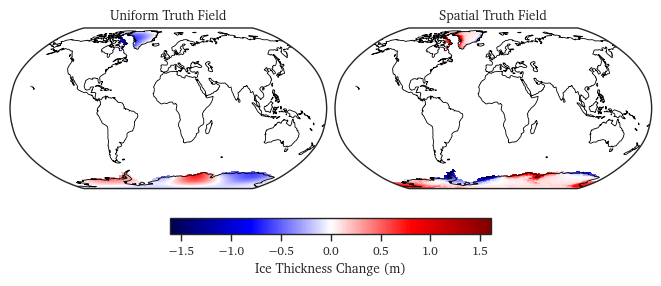

In [14]:
uniform_true = [
    r for r in results if r["truth"] == "uniform"
][0]["true_grid_m"]
spatial_true = [
    r for r in results if r["truth"] == "spatial"
][0]["true_grid_m"]

vmax = max(
    np.nanmax(np.abs(np.asarray(uniform_true.data))),
    np.nanmax(np.abs(np.asarray(spatial_true.data))),
)

fig = plt.figure(figsize=(6.5, 4), constrained_layout=True)
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.Robinson())
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.Robinson())

im1 = plot_shgrid_robinson_on_ax(
    uniform_true,
    ax1,
    cmap="seismic",
    symmetric=True,
    vmin=-vmax,
    vmax=vmax,
)
im2 = plot_shgrid_robinson_on_ax(
    spatial_true,
    ax2,
    cmap="seismic",
    symmetric=True,
    vmin=-vmax,
    vmax=vmax,
)
ax1.set_title("Uniform Truth Field")
ax2.set_title("Spatial Truth Field")

fig.colorbar(
    im2,
    ax=[ax1, ax2],
    orientation="horizontal",
    pad=0.08,
    shrink=0.5,
    label="Ice Thickness Change (m)",
)
sns.despine(left=True, bottom=True)
plt.show()

## Plot 2: Posterior GMSL PDFs for All Four Cases

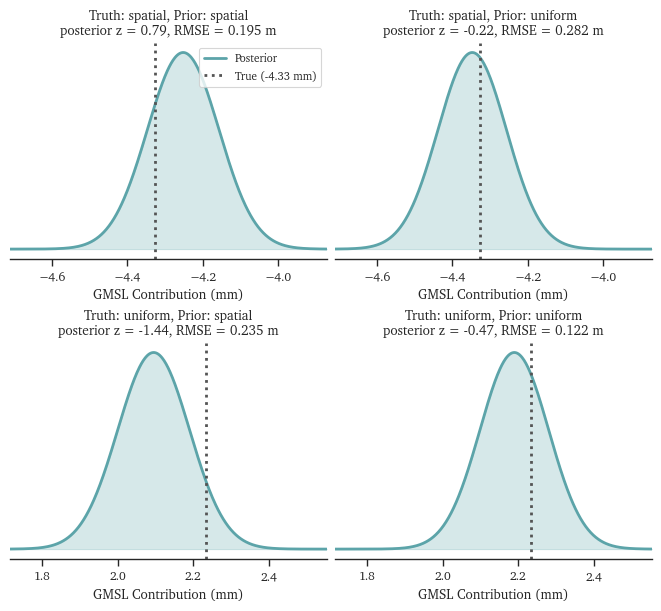

In [23]:
ordered = sorted(
    results, key=lambda r: (r["truth"], r["prior"])
)

# Compute row-wise x-limits so top and bottom rows each share a range.
row_x_limits = []
for row_idx in range(2):
    row_cases = ordered[row_idx * 2 : (row_idx + 1) * 2]
    row_x_min = min(
        min(
            case["posterior_mean_mm"]
            - 4 * case["posterior_std_mm"],
            case["gmsl_true_mm"],
        )
        for case in row_cases
    )
    row_x_max = max(
        max(
            case["posterior_mean_mm"]
            + 4 * case["posterior_std_mm"],
            case["gmsl_true_mm"],
        )
        for case in row_cases
    )
    row_x_limits.append((row_x_min, row_x_max))

fig, axes = plt.subplots(
    2, 2, figsize=(6.5, 6), constrained_layout=True
)
for idx, (ax, row) in enumerate(zip(axes.flat, ordered)):
    gtrue = row["gmsl_true_mm"]
    post_mean = row["posterior_mean_mm"]
    post_std = row["posterior_std_mm"]

    row_idx = idx // 2
    x_min, x_max = row_x_limits[row_idx]
    x = np.linspace(x_min, x_max, 500)

    post_pdf = stats.norm.pdf(x, post_mean, post_std)

    ax.fill_between(
        x, post_pdf, color=colors.new_method, alpha=0.25
    )
    ax.plot(
        x,
        post_pdf,
        color=colors.new_method,
        lw=2,
        label="Posterior",
    )
    ax.axvline(
        gtrue,
        color=colors.true,
        ls=":",
        lw=2,
        label=f"True ({gtrue:.2f} mm)",
    )

    ax.set_xlim(x_min, x_max)
    ax.set_title(
        f"Truth: {row['truth']}, Prior: {row['prior']}\n"
        f"posterior z = {row['posterior_z']:.2f}, RMSE = {row['rmse_m']:.3f} m"
    )
    ax.set_xlabel("GMSL Contribution (mm)")
    ax.get_yaxis().set_visible(False)

axes[0, 0].legend(loc="upper right", fontsize=8)
for ax in axes.flat:
    sns.despine(ax=ax, left=True)
plt.show()

## Plot 3: Posterior Mean Maps for All Four Cases

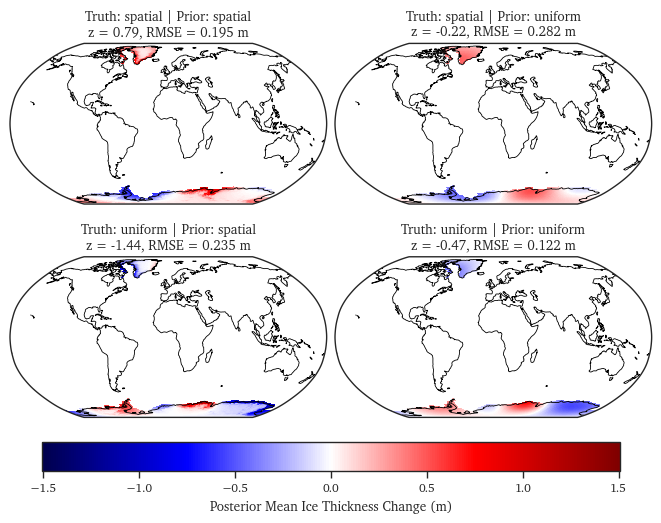

In [ ]:
ordered = sorted(
    results, key=lambda r: (r["truth"], r["prior"])
)
vmax = max(
    np.nanmax(np.abs(np.asarray(r["post_grid_m"].data)))
    for r in ordered
)

fig = plt.figure(
    figsize=(6.5, 5.2), constrained_layout=True
)
axes = [
    fig.add_subplot(2, 2, i + 1, projection=ccrs.Robinson())
    for i in range(4)
]

for ax, row in zip(axes, ordered):
    im = plot_shgrid_robinson_on_ax(
        row["post_grid_m"],
        ax,
        cmap="seismic",
        symmetric=True,
        vmin=-vmax,
        vmax=vmax,
    )
    ax.set_title(
        f"Truth: {row['truth']} | Prior: {row['prior']}\n"
        f"z = {row['posterior_z']:.2f}, RMSE = {row['rmse_m']:.3f} m"
    )

fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    pad=0.05,
    shrink=0.9,
    label="Posterior Mean Ice Thickness Change (m)",
)
plt.show()